<a href="https://colab.research.google.com/github/Chivirter/Chivirter/blob/main/Solar_Energy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

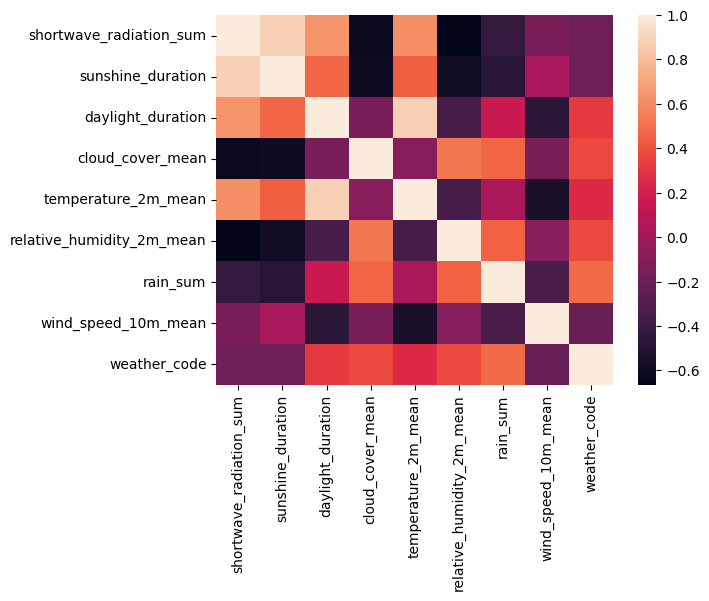

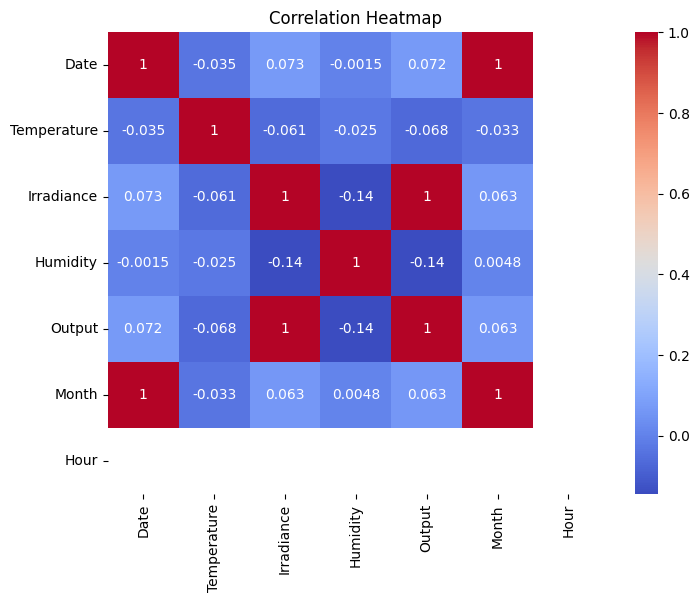

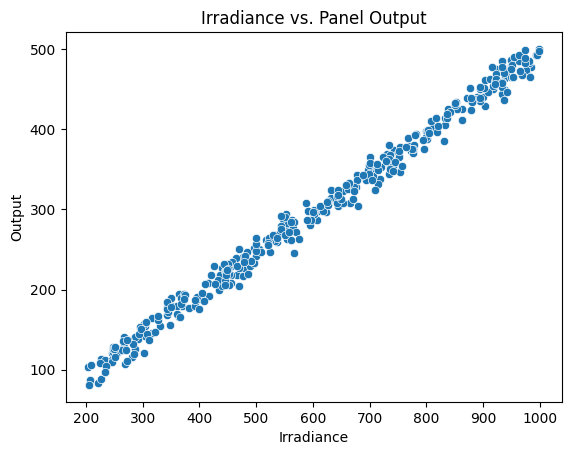

RMSE: 10.25
R² Score: 0.99


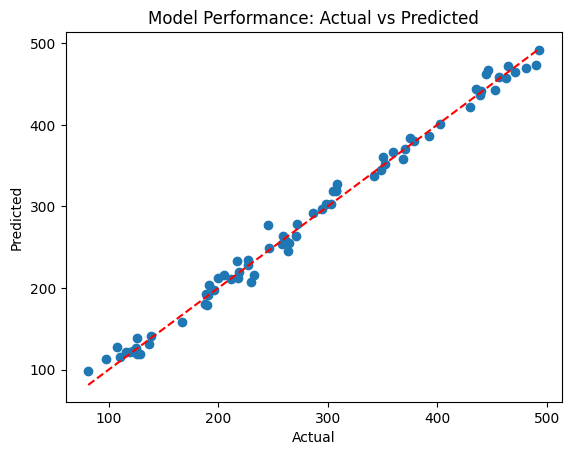

In [16]:
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
df = pd.read_csv('fact_weather_daily.csv')
df.isnull().sum()
sns.heatmap(df.corr(numeric_only=True))
sns.scatterplot()
import pandas as pd
import numpy as np

# If you have a file, use: df = pd.read_csv('your_file.csv')
# Here is a simulator to get you started:
dates = pd.date_range('2025-01-01', periods=365, freq='D')
df = pd.DataFrame({
    'Date': dates,
    'Temperature': np.random.uniform(10, 35, 365),
    'Irradiance': np.random.uniform(200, 1000, 365),
    'Humidity': np.random.uniform(30, 90, 365)
})
# Synthetic Output: Higher Irradiance + slight temp impact
df['Output'] = (df['Irradiance'] * 0.5) - (df['Temperature'] * 0.2) + np.random.normal(0, 10, 365)

# --- Cleaning & Preprocessing ---
df = df.dropna() # Drop missing
df['Month'] = df['Date'].dt.month
df['Hour'] = 12 # Assuming daily mid-day average
df.head()
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Irradiance vs Output
sns.scatterplot(data=df, x='Irradiance', y='Output')
plt.title('Irradiance vs. Panel Output')
plt.show()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select features
X = df[['Temperature', 'Irradiance', 'Humidity']]
y = df['Output']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.2f}")
print(f"R² Score: {r2_score(y_test, predictions):.2f}")

plt.scatter(y_test, predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Model Performance: Actual vs Predicted')
plt.show()